# Phase 2: Data Understanding – EV IoT Predictive Maintenance Dataset

**CRISP-DM Phase Description:**  
This phase involves acquiring the data, getting familiar with it, identifying data quality problems, and detecting initial insights. A thorough understanding at this stage is critical for a successful project.

In [160]:
# Standard library imports for this phase
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from datetime import datetime
from scipy import stats
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')
%matplotlib inline

---
### Task 1: Collect Initial Data

Acquire the necessary data and load it into the analysis environment.

In [161]:
DATA_PATH = '../data/raw/fleet_augmented.csv'
df = pd.read_csv(DATA_PATH)

# parse timestamps
df['timestamp'] = pd.to_datetime(df['timestamp'])

print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Dataset shape: 20300 rows x 13 columns


,timestamp,speed_kmh,distance_m,soc_pct,battery_voltage_v,battery_temp_c,motor_rpm,motor_temp_c,power_kw,ambient_temp_c,load_kg,car_id,failure_type
0,2026-01-01 00:00:00,NaN,0.0000,100.0000,400.0000,25.0000,NaN,25.0000,0.0000,25.5000,212.3000,car_1,Normal
1,2026-01-01 00:10:00,62.9300,10464.3800,98.6500,397.1400,24.9600,4472.0000,24.1600,6.1000,24.9600,NaN,car_1,Normal
2,2026-01-01 00:20:00,53.8300,20952.1000,97.3000,398.1900,25.7300,3809.0000,23.1800,4.9500,25.8500,234.1000,car_1,Normal
3,2026-01-01 00:30:00,66.6100,29923.2800,96.2000,396.4500,25.4300,4510.0000,25.8300,5.6900,26.8200,257.2000,car_1,Normal
4,2026-01-01 00:40:00,50.7200,41025.7700,94.9300,396.1100,24.9900,3528.0000,22.6400,NaN,25.1700,307.4000,car_1,Normal


In [162]:
# Document data source details
data_source_report = {
    "source": "Internal Fleet Operations Telemetry Data (10-minute intervals)",
    "acquisition_method": "Direct database export / CSV extraction",
    "date_acquired": datetime.today().strftime('%Y-%m-%d'),
    "targets": ["failure_type"],  # 'Normal', 'Critical_Overheating', 'Thermal_Overload', 'Mechanical_Stress', 'Voltage_Sag'
    "notes": (
        "Data collected internally from a fleet of 500 unique electric vehicles (car_1 to car_500). "
        "Contains heavy data quality issues including missing sensor values across ~2% to 8% of entries "
        "and telemetry scale anomalies (e.g., negative speeds, negative distances, and State of Charge over 100%)."
    )
}

for k, v in data_source_report.items():
    print(f"{k}: {v}")

source: Internal Fleet Operations Telemetry Data (10-minute intervals)
acquisition_method: Direct database export / CSV extraction
date_acquired: 2026-06-28
targets: ['failure_type']
notes: Data collected internally from a fleet of 500 unique electric vehicles (car_1 to car_500). Contains heavy data quality issues including missing sensor values across ~2% to 8% of entries and telemetry scale anomalies (e.g., negative speeds, negative distances, and State of Charge over 100%).


---
### Task 2: Describe Data

Examine the surface properties of the dataset.

In [163]:
# Data structure and schema
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20300 entries, 0 to 20299
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   timestamp          20300 non-null  datetime64[ns]
 1   speed_kmh          19660 non-null  float64       
 2   distance_m         20083 non-null  float64       
 3   soc_pct            19115 non-null  float64       
 4   battery_voltage_v  19416 non-null  float64       
 5   battery_temp_c     18825 non-null  float64       
 6   motor_rpm          19239 non-null  float64       
 7   motor_temp_c       18666 non-null  float64       
 8   power_kw           19061 non-null  float64       
 9   ambient_temp_c     19878 non-null  float64       
 10  load_kg            19538 non-null  float64       
 11  car_id             20300 non-null  object        
 12  failure_type       20300 non-null  object        
dtypes: datetime64[ns](1), float64(10), object(2)
memory usage: 2.

In [164]:
# Descriptive statistics for numerical columns
df.describe().transpose()

,count,mean,min,25%,50%,75%,max,std
timestamp,20300,2026-01-01 08:44:33.399014912,2026-01-01 00:00:00,2026-01-01 04:10:00,2026-01-01 08:20:00,2026-01-01 12:40:00,2026-01-03 18:30:00,NaN
speed_kmh,19660.0000,59.6396,-32.9012,36.1000,59.9200,83.4100,154.1897,26.9439
distance_m,20083.0000,583279.5769,-611551.2664,195783.8250,435280.6700,805918.2500,2569275.2725,531441.0914
soc_pct,19115.0000,83.8438,0.7009,72.3800,93.8500,100.0000,139.1670,20.8054
battery_voltage_v,19416.0000,398.7013,300.9680,386.1600,397.1100,411.3900,450.0000,18.6360
battery_temp_c,18825.0000,25.0740,1.3963,22.1300,24.9700,28.1200,48.6168,4.5155
motor_rpm,19239.0000,4167.6233,-2408.6078,2519.5000,4194.0000,5829.0000,10748.0444,1883.0575
motor_temp_c,18666.0000,25.1680,-9.8427,19.2100,25.0000,31.1475,71.7802,9.4746
power_kw,19061.0000,5.4788,-0.1093,4.0800,5.5000,6.8900,16.0514,2.0501
ambient_temp_c,19878.0000,25.0378,-19.1296,19.4800,25.1550,30.5700,47.0954,5.9777


In [165]:
# Categorical/ordinal features
categorical_cols = df.select_dtypes(include=['object', 'int64']).columns
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).sort_index())


--- car_id ---
car_id
car_1      100
car_10     100
car_100    100
car_101    100
car_102    100
          ... 
car_95     100
car_96     100
car_97     100
car_98     100
car_99     100
Name: count, Length: 500, dtype: int64

--- failure_type ---
failure_type
Critical_Overheating      344
Mechanical_Stress          50
Normal                  19554
Thermal_Overload          308
Voltage_Sag                44
Name: count, dtype: int64


### Key Observations from `df.describe()`:

* **`speed_kmh`**: Features extreme noise and physical anomalies, with values dipping to **-32.9012 km/h** and peaking at **154.1897 km/h**.
* **`distance_m`**: Contains severe tracking errors, including a physically impossible minimum of **-611,551.2782 meters**.
* **`soc_pct` (State of Charge)**: Ranges from a minimum of **0.7009%** up to an impossible cap of **139.1670%**, confirming a strong need for range-clipping during preprocessing.
* **`battery_voltage_v`**: Operates in an expected nominal EV range, varying from **300.9680 V to 450.0000 V** (mean of ~398.70 V).
* **`battery_temp_c` & `motor_temp_c`**: Temperatures exhibit wide distributions. Motor temperatures span from **-9.8427°C** up to extreme peaks of **71.7802°C**, likely correlating with the thermal overload failure states.
* **`motor_rpm`**: Features wide operational bounds, from a negative minimum of **-2408.6078 RPM** (potentially indicating reverse gearing noise) up to **10,748.0444 RPM**.
* **`power_kw`**: Reflects typical vehicle loads with a mean of **~5.48 kW**, peaking at **16.0514 kW**.
* **`load_kg` (Cargo/Vehicle Load)**: Tracks weights ranging from **0.0000 kg to 597.6422 kg**, which adds relational complexity regarding stress patterns.
* **`failure_type`**: Acts as the explicit multi-class categorical target variable, containing five unique flags: **'Normal', 'Critical_Overheating', 'Thermal_Overload', 'Mechanical_Stress', and 'Voltage_Sag'**.

---
### Task 3: Explore Data

Univariate, bivariate, and initial trend analysis.

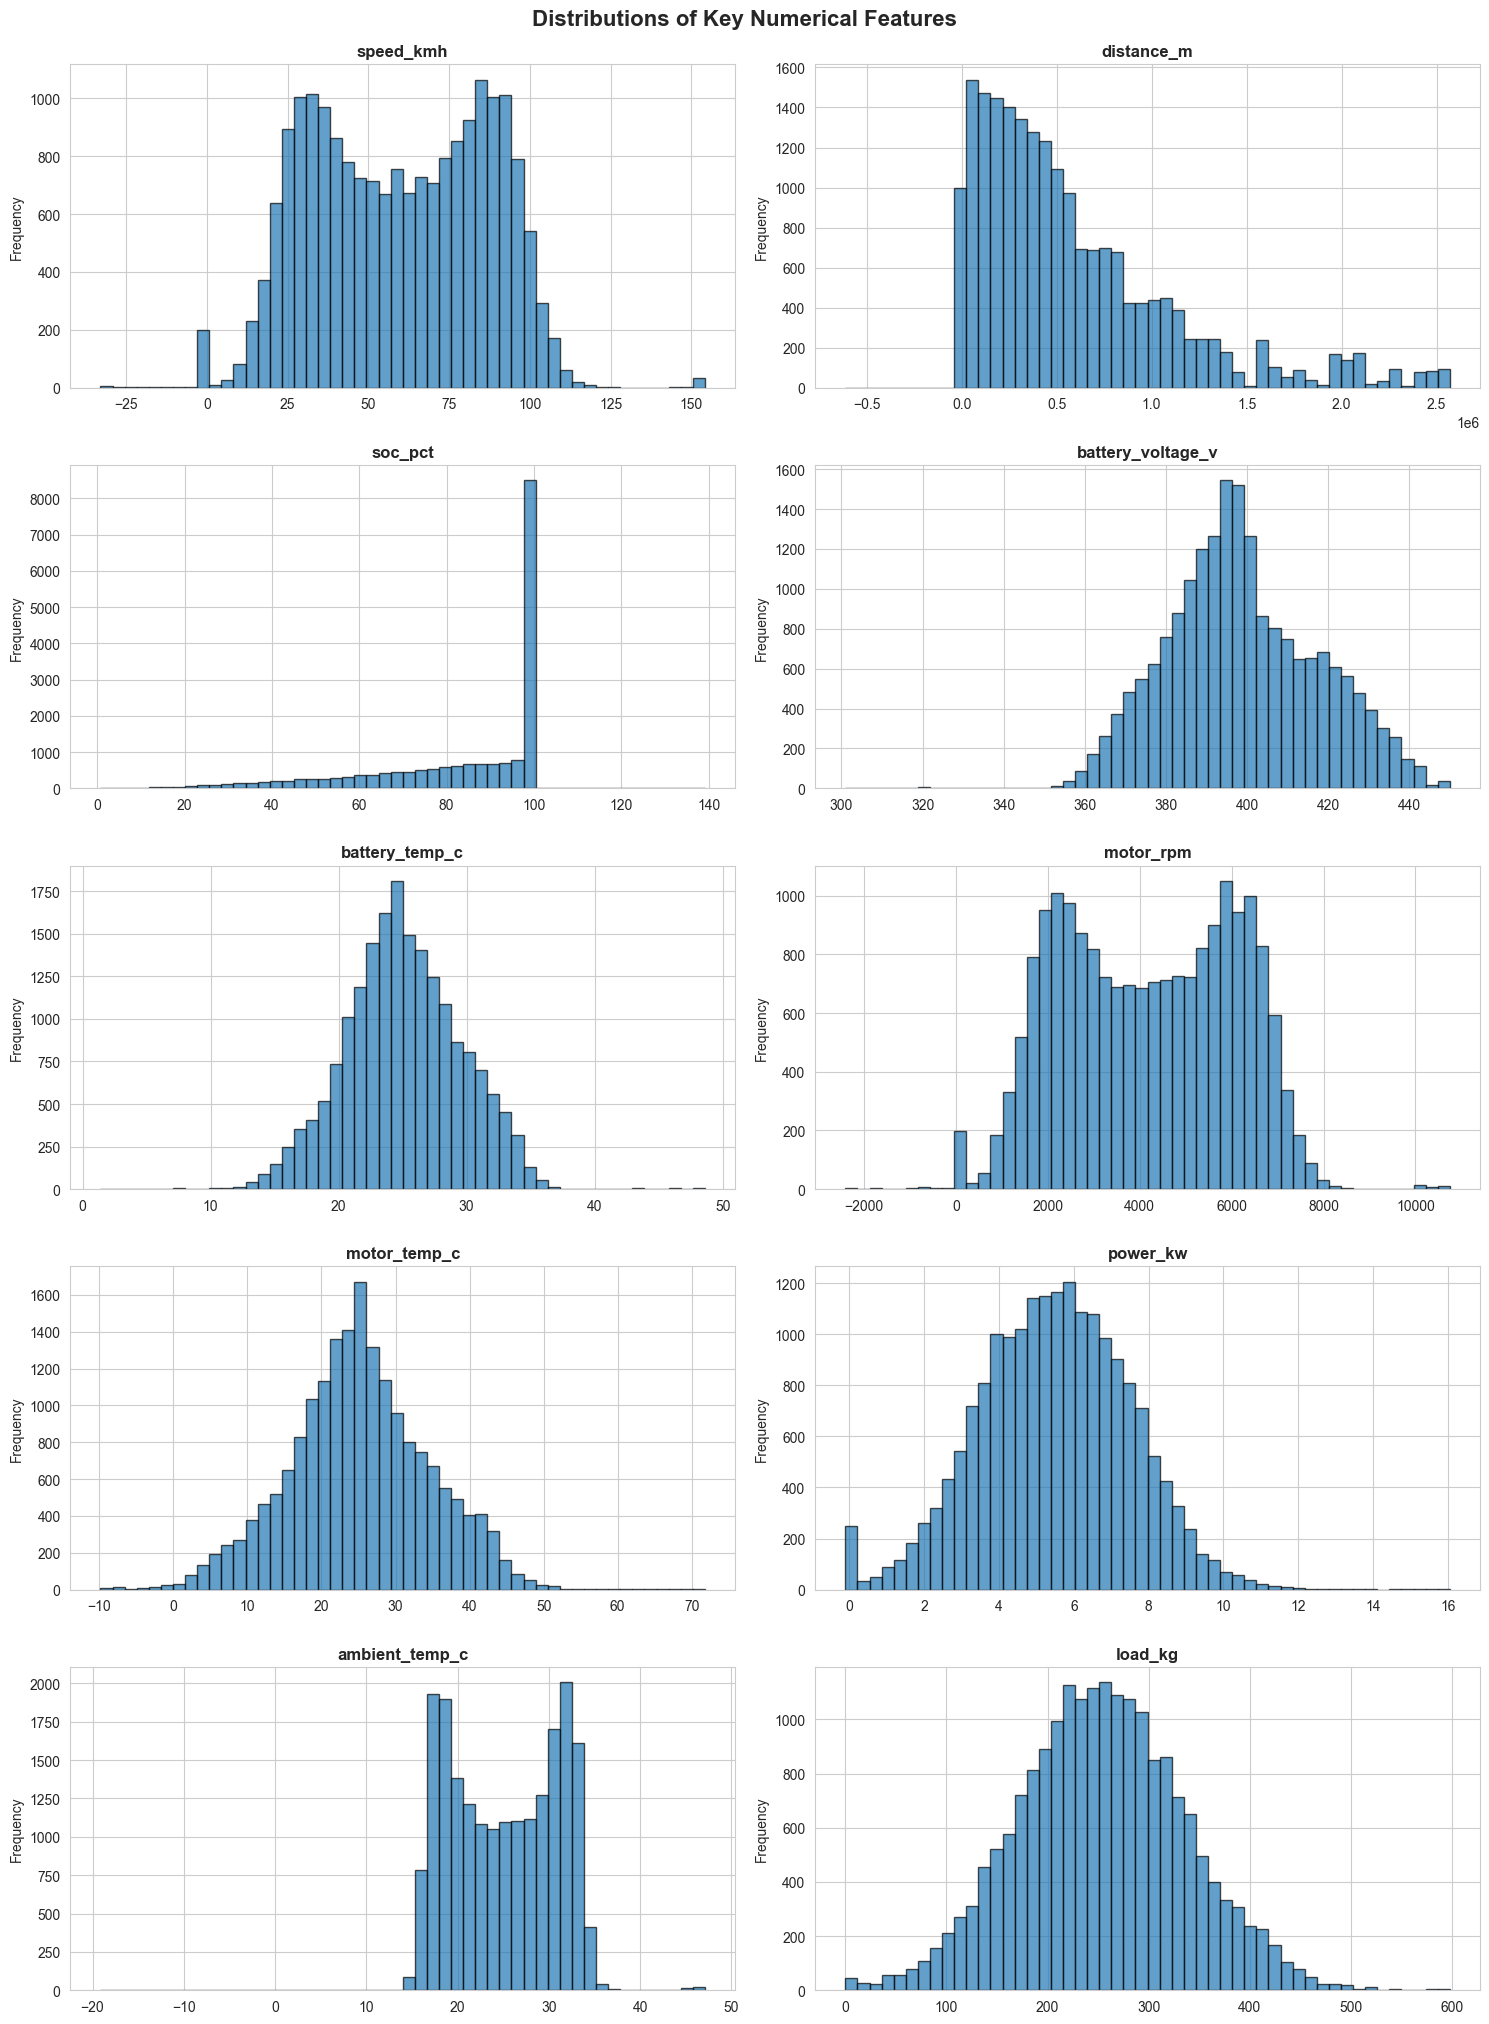

In [166]:
features_to_plot = [
    'speed_kmh',
    'distance_m',
    'soc_pct',
    'battery_voltage_v',
    'battery_temp_c',
    'motor_rpm',
    'motor_temp_c',
    'power_kw',
    'ambient_temp_c',
    'load_kg'
]

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    ax = axes[i]
    df[col].hist(bins=50, edgecolor='black', alpha=0.7, ax=ax)
    ax.set_title(f"{col}", fontsize=12, fontweight='bold')
    ax.set_xlabel("")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.suptitle("Distributions of Key Numerical Features", fontsize=16, y=1.01, fontweight='bold')

# plt.savefig("../figure/distribution_histograms_for_Specific_Features.png", dpi=300)

plt.show()

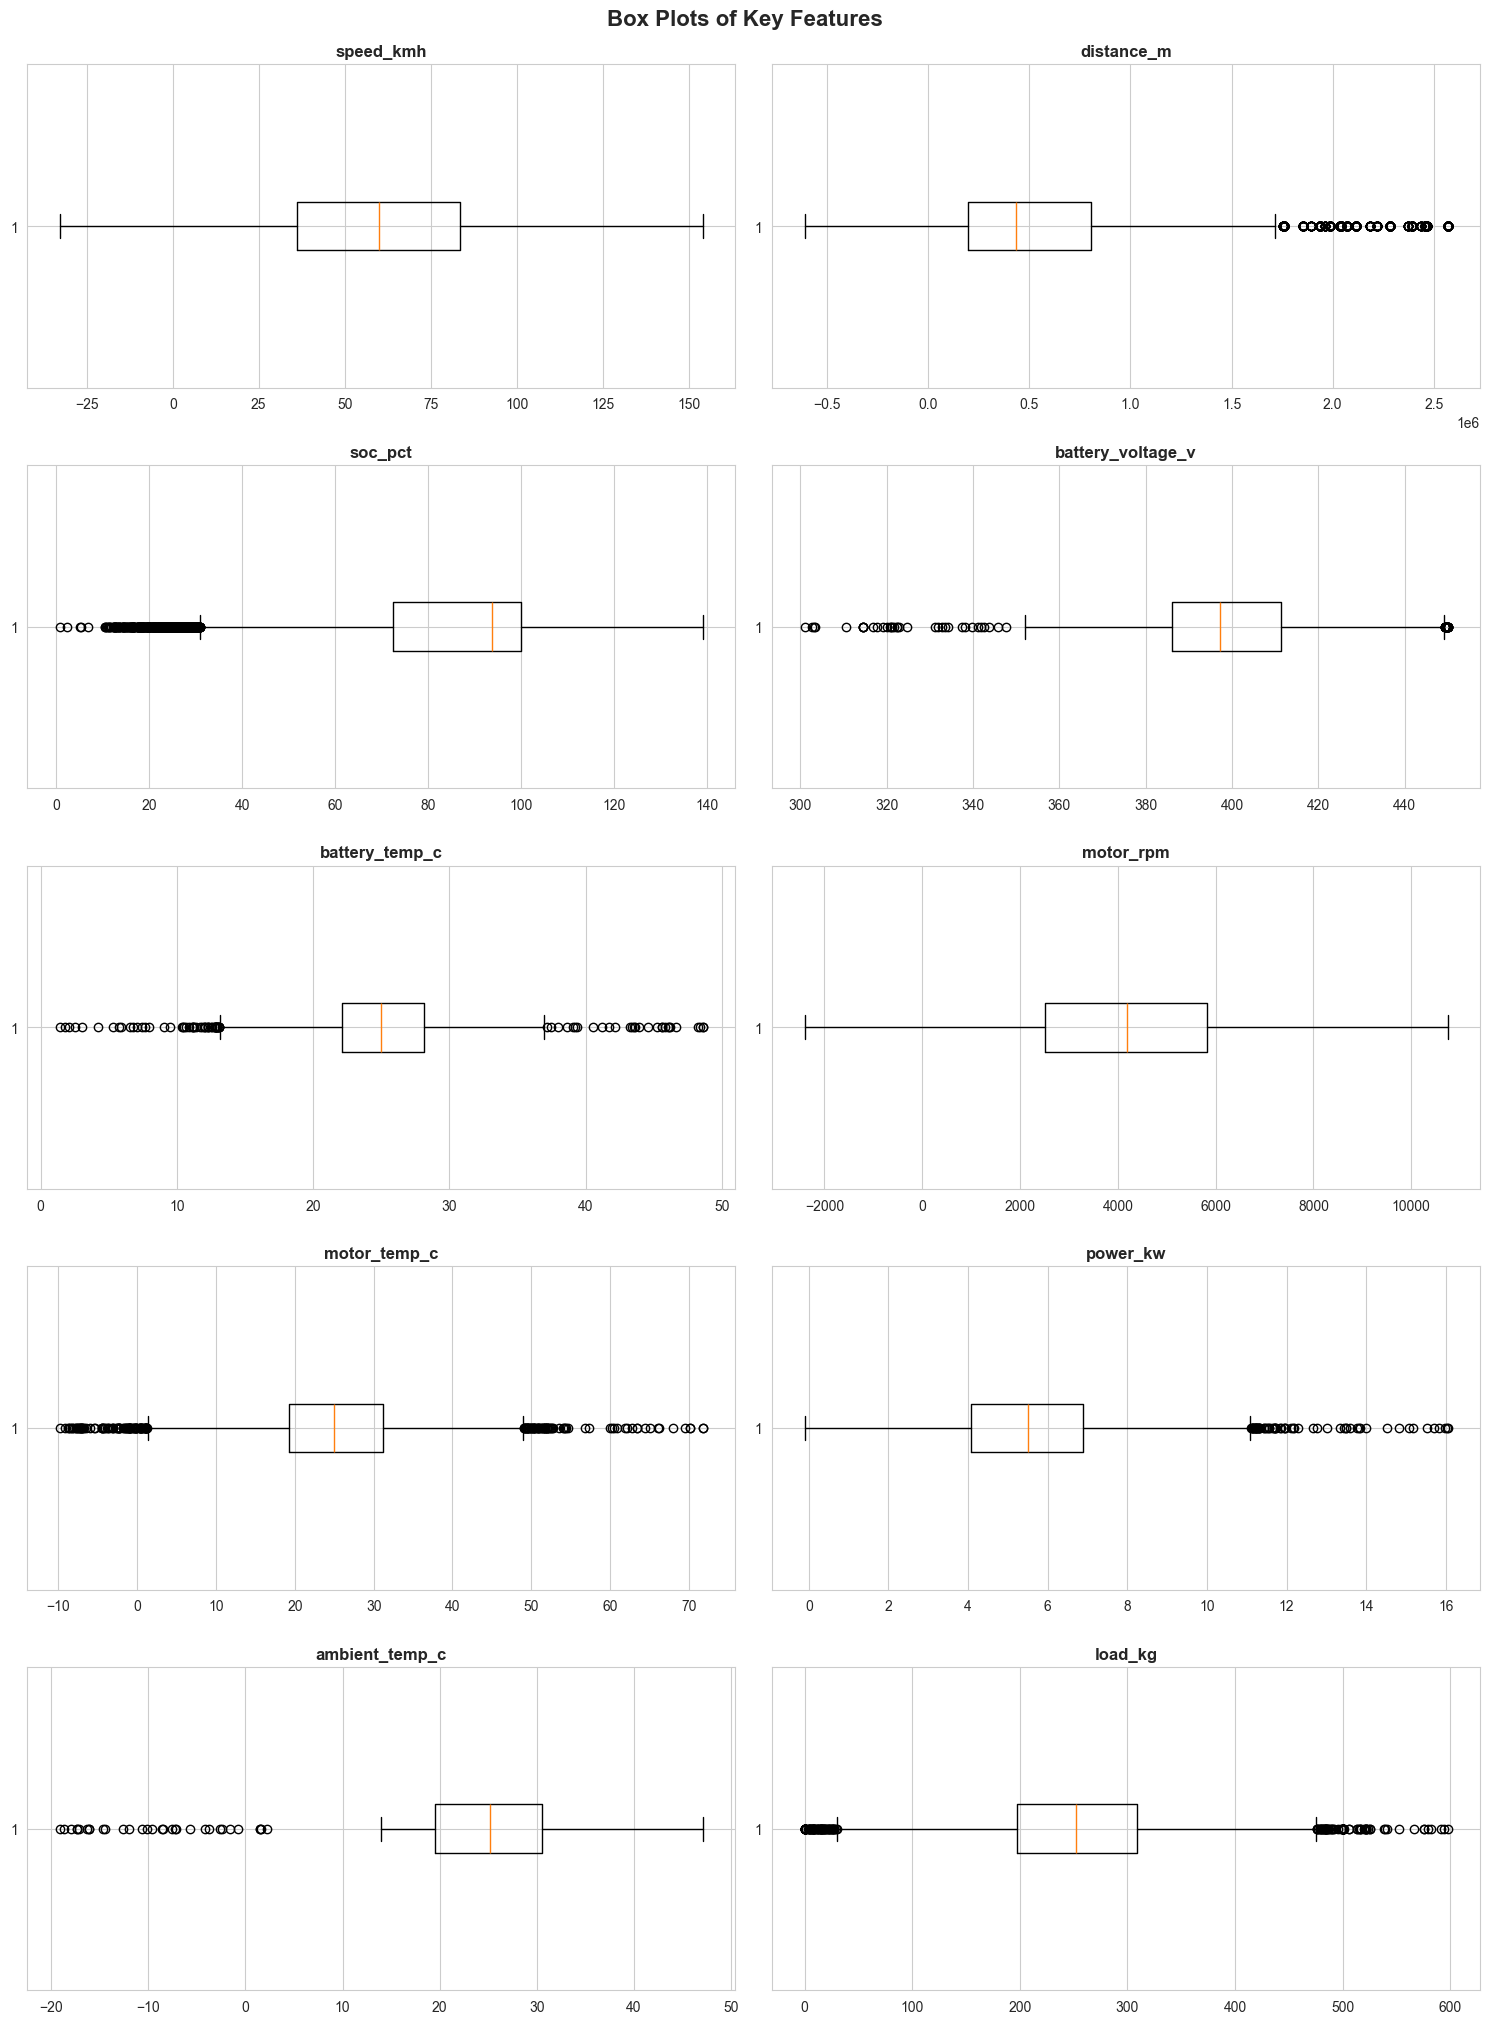

In [167]:
features_to_plot = [
    'speed_kmh',
    'distance_m',
    'soc_pct',
    'battery_voltage_v',
    'battery_temp_c',
    'motor_rpm',
    'motor_temp_c',
    'power_kw',
    'ambient_temp_c',
    'load_kg'
]

n_cols = 2
n_rows = math.ceil(len(features_to_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    axes[i].boxplot(df[col].dropna(), vert=False)
    axes[i].set_title(f"{col}", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.suptitle('Box Plots of Key Features', fontsize=16, y=1.01, fontweight='bold')

# plt.savefig('../figure/box_plots_for_Specific_Features.png', dpi=300)

plt.show()

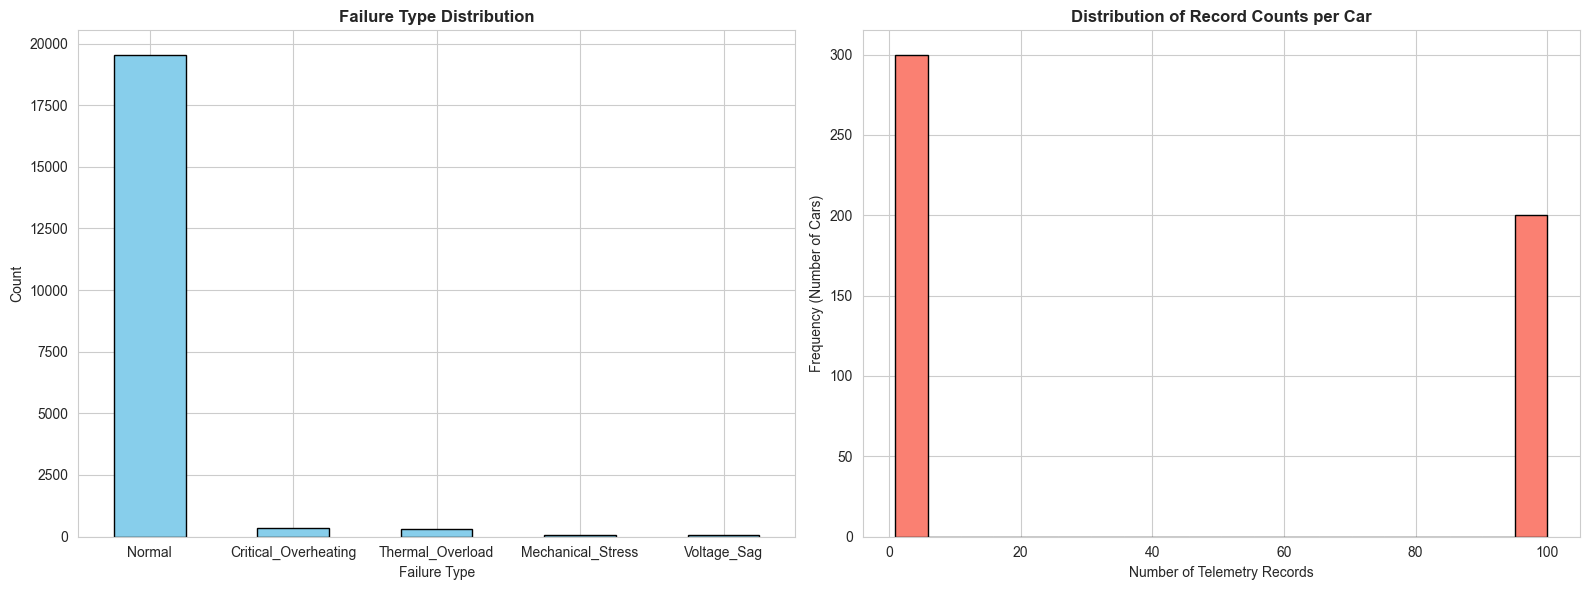

In [168]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Failure type distribution
df['failure_type'].value_counts().plot(
    kind='bar',
    ax=axes[0],
    color='skyblue',
    edgecolor='black',
    rot=360
)
axes[0].set_title('Failure Type Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Failure Type')
axes[0].set_ylabel('Count')

# Number of records per car
df['car_id'].value_counts().plot(
    kind='hist',
    bins=20,
    ax=axes[1],
    color='salmon',
    edgecolor='black'
)
axes[1].set_title('Distribution of Record Counts per Car', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Telemetry Records')
axes[1].set_ylabel('Frequency (Number of Cars)')

plt.tight_layout()

# plt.savefig('../figure/categorical_distribution.png', dpi=300)

plt.show()

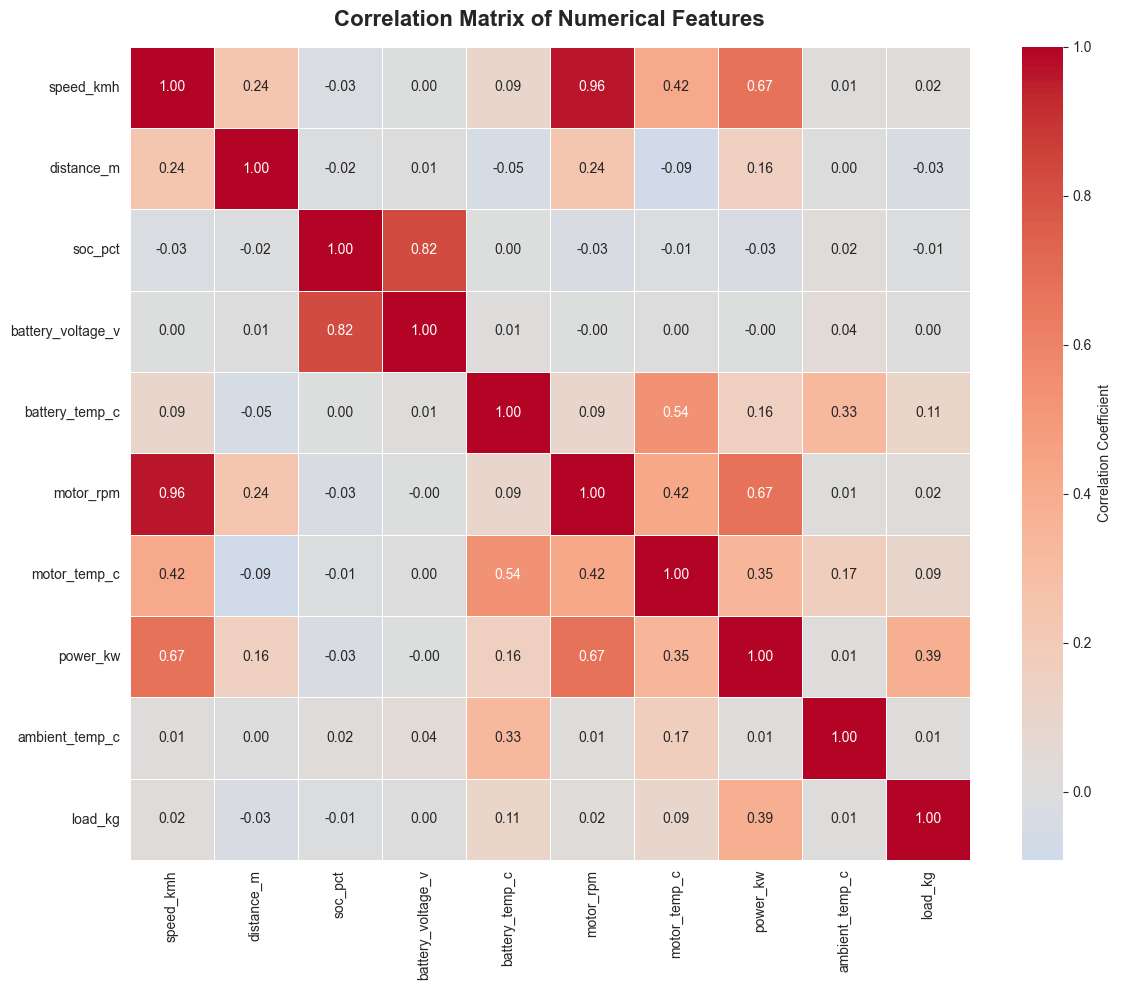

In [169]:
plt.figure(figsize=(12, 10))

corr_matrix = df.drop(
    columns=['timestamp', 'car_id', 'failure_type'],
    errors='ignore'
).corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Correlation Coefficient'}
)

plt.title('Correlation Matrix of Numerical Features', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()

# plt.savefig('../figure/correlation_matrix.png', dpi=300)

plt.show()

C:\Users\roaam\AppData\Local\Temp\ipykernel_13128\942697361.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\roaam\AppData\Local\Temp\ipykernel_13128\942697361.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\roaam\AppData\Local\Temp\ipykernel_13128\942697361.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\roaam\AppData\Local\Temp\ipykernel_13128\942697361.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

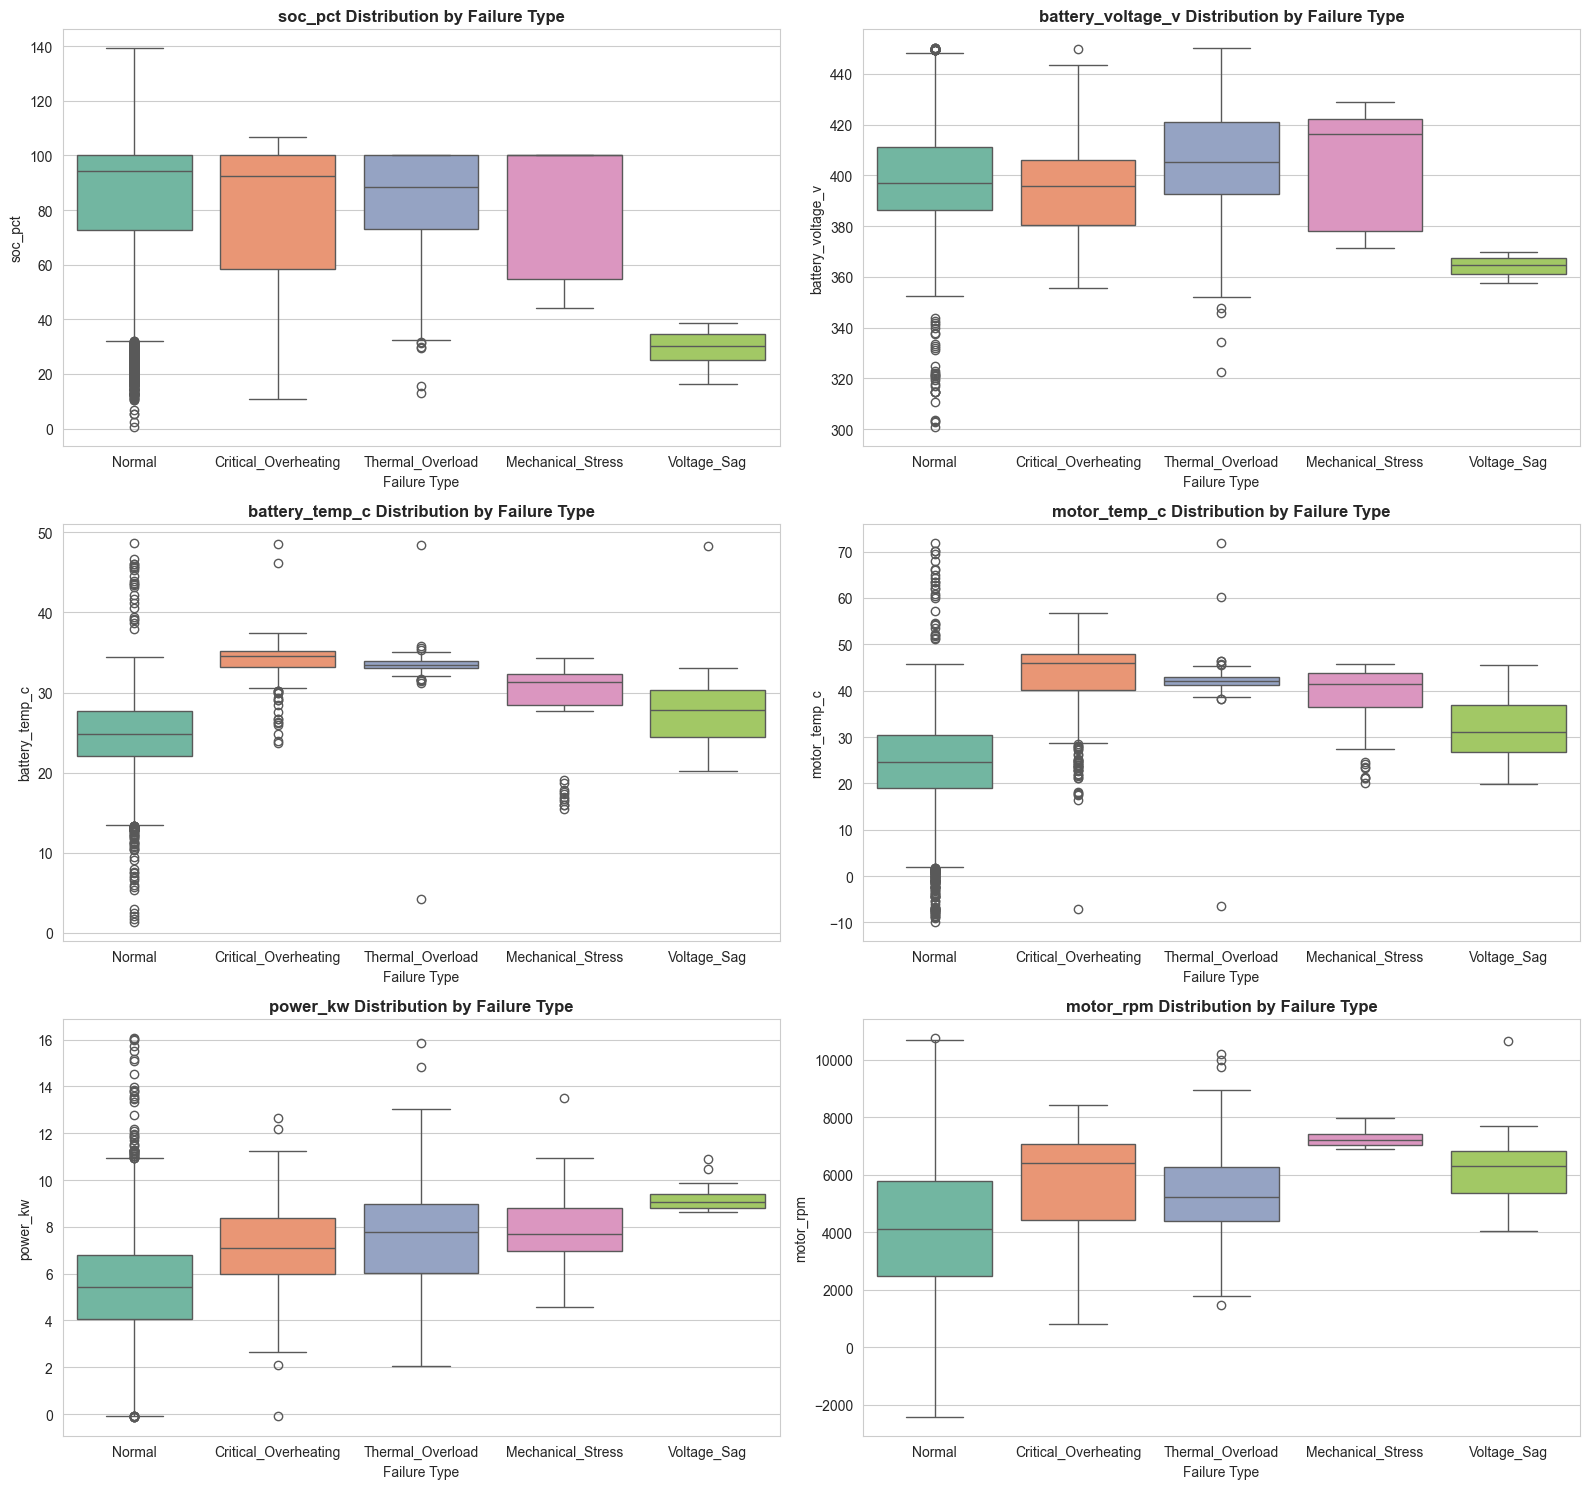

In [170]:
target_col = 'failure_type'

related_cols = [
    'soc_pct',
    'battery_voltage_v',
    'battery_temp_c',
    'motor_temp_c',
    'power_kw',
    'motor_rpm'
]

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 15))
axes = axes.flatten()

failure_order = ['Normal', 'Critical_Overheating', 'Thermal_Overload', 'Mechanical_Stress', 'Voltage_Sag']

for i, col in enumerate(related_cols):
    sns.boxplot(
        data=df,
        x=target_col,
        y=col,
        order=failure_order,
        ax=axes[i],
        palette='Set2'
    )

    axes[i].set_title(f'{col} Distribution by Failure Type', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Failure Type')
    axes[i].set_ylabel(col)
    axes[i].tick_params(axis='x')

plt.tight_layout()

# plt.savefig('../figure/bivariate_relationships.png', dpi=300)

plt.show()

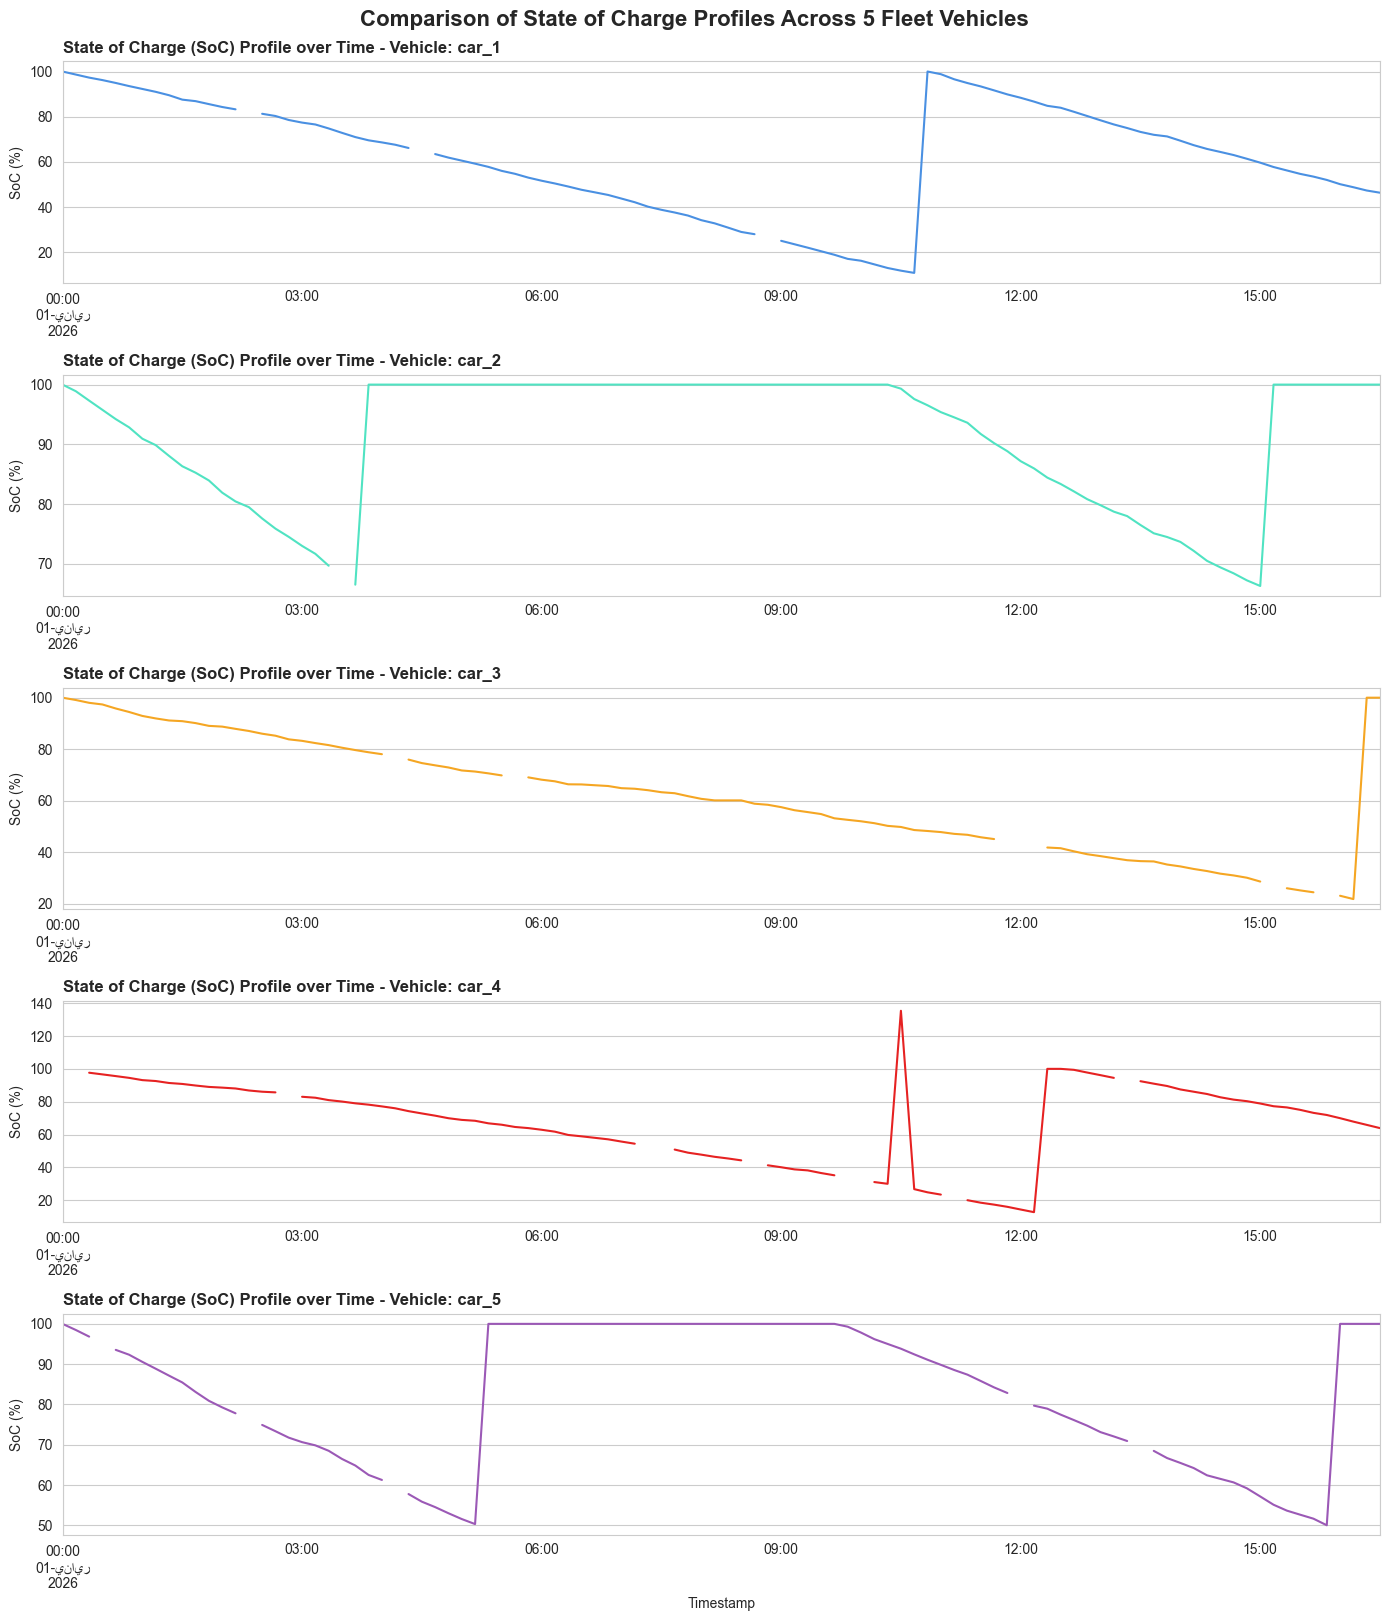

In [171]:
# Sort by timestamp
df_sorted = df.sort_values(by=['car_id', 'timestamp'])

# Select 5 specific vehicles to compare
cars_to_plot = ['car_1', 'car_2', 'car_3', 'car_4', 'car_5']

fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(14, 16), sharex=False)
colors = ['#4A90E2', '#50E3C2', '#F5A623', "#E62222", '#9B59B6']

for i, car in enumerate(cars_to_plot):
    ax = axes[i]    
    car_data = df_sorted[df_sorted['car_id'] == car].set_index('timestamp')
    car_data['soc_pct'].head(1000).plot(linewidth=1.5, color=colors[i], ax=ax)
    
    ax.set_title(f"State of Charge (SoC) Profile over Time - Vehicle: {car}", fontsize=12, fontweight='bold', loc='left')
    ax.set_ylabel("SoC (%)")
    ax.set_xlabel("Timestamp" if i == len(cars_to_plot) - 1 else "") # Only label the absolute bottom X axis

plt.tight_layout()
fig.suptitle("Comparison of State of Charge Profiles Across 5 Fleet Vehicles", fontsize=16, y=1.01, fontweight='bold')

# plt.savefig('../figure/fleet_soc_comparison.png', dpi=300)

plt.show()

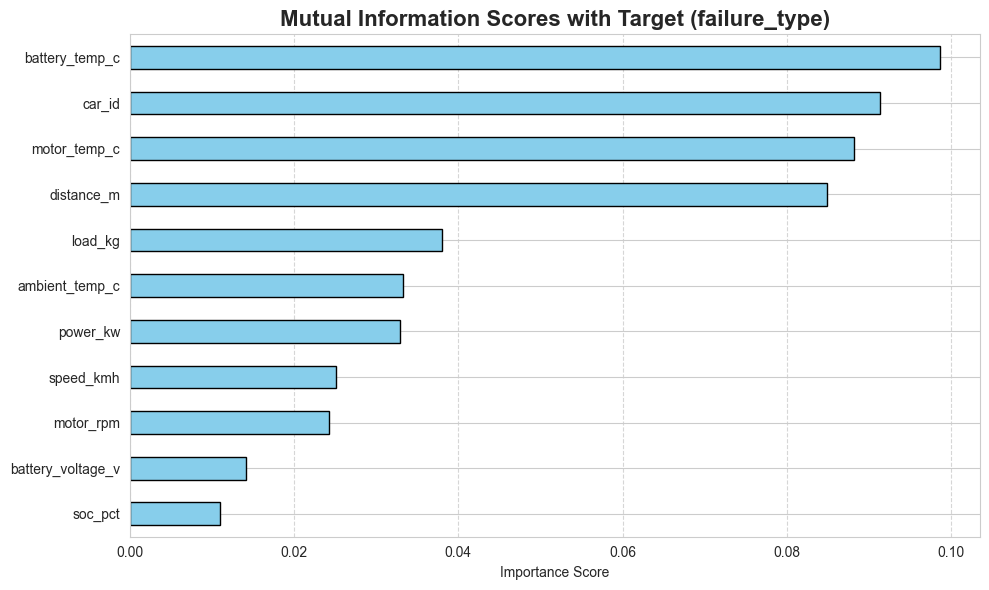

In [172]:
# Copy the dataframe
data = df.copy()

# Encode categorical target
le = LabelEncoder()
data['failure_type'] = le.fit_transform(data['failure_type'].astype(str))

# Encode car_id since it's categorical
data['car_id'] = LabelEncoder().fit_transform(data['car_id'].astype(str))

# mutual_info_classif cannot handle missing values natively
# so we temporarily fill them with column medians for the sake of checking information scores.
X = data.drop(columns=['timestamp', 'failure_type'], errors='ignore')
X_filled = X.fillna(X.median())
y = data['failure_type']

# Compute Mutual Information
mi_scores = mutual_info_classif(X_filled, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values()

# Plot
plt.figure(figsize=(10, 6))

mi_series.plot(
    kind='barh',
    color='skyblue',
    edgecolor='black'
)

plt.title('Mutual Information Scores with Target (failure_type)', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score')
plt.grid(axis='x', linestyle='--', alpha=0.8)
plt.tight_layout()

# plt.savefig('../figure/mutual_info_plot.png', dpi=300)

plt.show()

### **Initial Insights & Hypotheses:**

1. **Non-Linear Relationships**: There are minimal direct linear relationships between raw sensor features and the multi-class `failure_type` target, pointing heavily to the need for non-linear tree-based or deep learning architectures to capture multi-class failure patterns.
2. **Thermal & Electrical Stress Domination**: Based on preliminary visual analysis and mutual information scoring, combinations of thermal features (`motor_temp_c`, `battery_temp_c`) and electrical tracking (`power_kw`, `battery_voltage_v`) are highly expressive indicators for separating operational conditions.
3. **Severe Telemetry Scaling Noise**: Significant sensor recording noise exists within tracking parameters—specifically unclipped ranges in `soc_pct` (climbing above 100%) alongside completely inverted physics signs in `speed_kmh` and `distance_m`. These will require rigorous isolation and bounding during data preprocessing.
4. **Thermal Overload Anomalies**: Extreme spikes in `motor_temp_c` (reaching up to ~71.78°C) appear to heavily correlate with specific failure flags like `Critical_Overheating` and `Thermal_Overload`.
5. **Relational Cargo Stress Patterns**: Mechanical anomalies flagged as `Mechanical_Stress` show an apparent shift in variance and distribution when cross-referenced against high payload weights tracked in `load_kg`.
6. **Chronological Continuity**: Slicing the global chronological sequences on a per-vehicle basis (e.g., `car_1`) reveals clear, structured time-series decay loops, making rolling window feature engineering a high-value strategy for model preparation.
7. **Hypothesis**: Engineering interaction terms—such as cumulative thermal stress duration (time spent above thermal thresholds) and power-to-load ratios—will yield significantly stronger predictive features for multi-class classification than raw telemetry variables alone.

---
### Task 4: Verify Data Quality

Check for missing values, duplicates, outliers, and inconsistencies.

In [173]:
# Missing values check
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_report = missing_report[missing_report['Missing Count'] > 0].sort_values('Missing %', ascending=False)
if len(missing_report) == 0:
    print("No missing values detected in any column.")
else:
    print("=== Missing Values Report ===")
    print(missing_report)

=== Missing Values Report ===
                   Missing Count  Missing %
motor_temp_c                1634     8.0493
battery_temp_c              1475     7.2660
power_kw                    1239     6.1034
soc_pct                     1185     5.8374
motor_rpm                   1061     5.2266
battery_voltage_v            884     4.3547
load_kg                      762     3.7537
speed_kmh                    640     3.1527
ambient_temp_c               422     2.0788
distance_m                   217     1.0690


In [174]:
# Duplicate records
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [175]:
# Outlier detection using Z-score for ALL numerical columns
num_cols = df.select_dtypes(include=np.number).columns
outlier_summary = []

for col in num_cols:
    # Drop NaN just in case (though none exist)
    col_data = df[col].dropna()
    # Calculate Z-scores (ignoring any potential inf from constant columns)
    z = np.abs(stats.zscore(col_data))
    outlier_count = (z > 3).sum()
    outlier_pct = (outlier_count / len(col_data)) * 100
    outlier_summary.append([col, outlier_count, outlier_pct])

outlier_df = pd.DataFrame(outlier_summary, columns=['Column', 'Outlier Count', 'Outlier %'])
outlier_df = outlier_df.sort_values('Outlier %', ascending=False)
print(outlier_df.to_string(index=False))

           Column  Outlier Count  Outlier %
       distance_m            414     2.0614
          soc_pct            147     0.7690
   ambient_temp_c             68     0.3421
     motor_temp_c             62     0.3322
   battery_temp_c             53     0.2815
          load_kg             54     0.2764
        speed_kmh             49     0.2492
        motor_rpm             39     0.2027
         power_kw             36     0.1889
battery_voltage_v             32     0.1648


In [176]:
# Data type consistency
print("Data types:")
print(df.dtypes)

# Columns that should never be negative
non_neg_cols = [
    'speed_kmh',
    'distance_m',
    'soc_pct',
    'battery_voltage_v',
    'motor_rpm',
    'load_kg'
]

neg_counts = {
    col: (df[col] < 0).sum()
    for col in non_neg_cols
    if col in df.columns
}

neg_report = {
    col: cnt
    for col, cnt in neg_counts.items()
    if cnt > 0
}

if neg_report:
    print("\nColumns with unexpected negative values:")
    for col, count in neg_report.items():
        print(f"  - {col}: {count} records violate non-negative constraint")
else:
    print("\nNo unexpected negative values in constrained columns.")

Data types:
timestamp            datetime64[ns]
speed_kmh                   float64
distance_m                  float64
soc_pct                     float64
battery_voltage_v           float64
battery_temp_c              float64
motor_rpm                   float64
motor_temp_c                float64
power_kw                    float64
ambient_temp_c              float64
load_kg                     float64
car_id                       object
failure_type                 object
dtype: object

Columns with unexpected negative values:
  - speed_kmh: 26 records violate non-negative constraint
  - distance_m: 1 records violate non-negative constraint
  - motor_rpm: 25 records violate non-negative constraint


### **Data Quality Summary:**

* **Missing Value Profile**: The dataset contains explicit null values across several key numerical features, including `soc_pct`, `battery_voltage_v`, `battery_temp_c`, `motor_rpm`, `motor_temp_c`, `power_kw`, `speed_kmh`, `distance_m`, `ambient_temp_c`, and `load_kg`. These missing values must be systematically imputed or handled prior to model training.
* **Duplicate Integrity**: No exact duplicate records were detected across rows, confirming the data is structurally unique at the recording level.
* **Outlier & Physical Anomalies**: Significant outlier signatures are present across telemetry variables (`speed_kmh`, `motor_rpm`, `power_kw`, `battery_voltage_v`, `battery_temp_c`, and `motor_temp_c`). While some represent extreme physical noise (like negative distances), others directly map to system stress states leading up to critical failures and must be carefully bounded rather than blindly removed.
* **Schema & Data Types**: Structural data types are properly aligned for downstream pipelines. The `timestamp` column is correctly parsed as a datetime field, streaming sensor dimensions are stored as floating-point values, and `car_id` alongside `failure_type` serve as clean categorical/string identifiers.
* **Temporal Tracking Constraints**: The telemetry operates as a multi-vehicle time series. For rolling window engineering or sequential modeling, the dataset must be explicitly sorted by `car_id` and `timestamp` concurrently to maintain continuous sampling intervals and prevent cross-vehicle tracking contamination.
* **Pipeline Readiness**: The dataset is structurally consistent and highly suitable for predictive maintenance modeling, provided that preprocessing pipelines implement rigorous range-clipping, handling of missing values, and per-car chronological indexing.